In [1]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/energy_features.parquet"
)

print(df.shape)

df.head()

(9234, 17)


,SETTLEMENT_DATE,ND,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,year,month,quarter,day_of_week,day_of_year,is_weekend,is_month_start,is_month_end
0,2001-01-31,46597.395833,47262.625000,45456.041667,35616.520833,44440.758929,42233.740278,3153.298452,5740.278568,2001,1,1,2,31,0,0,1
1,2001-02-01,41944.395833,46597.395833,45680.666667,47423.416667,43907.005952,42051.106250,3223.868240,5656.011348,2001,2,1,3,32,0,1,0
2,2001-02-02,45810.083333,41944.395833,45307.333333,47082.916667,43978.827381,42008.678472,3265.594308,5621.633876,2001,2,1,4,33,0,0,0
3,2001-02-03,46615.208333,45810.083333,40430.729167,34527.708333,44862.324405,42411.595139,2968.786838,5498.793610,2001,2,1,5,34,1,0,0
4,2001-02-04,40129.416667,46615.208333,39442.833333,39791.687500,44960.407738,42422.852778,2764.186485,5493.588188,2001,2,1,6,35,1,0,0


In [3]:
TARGET = "ND"

FEATURES = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30",
    "year",
    "month",
    "quarter",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "is_month_start",
    "is_month_end"
]

X = df[FEATURES]

y = df[TARGET]

In [4]:
split_date = "2024-01-01"

train = df[
    df["SETTLEMENT_DATE"] < split_date
]

test = df[
    df["SETTLEMENT_DATE"] >= split_date
]

print(train.shape)
print(test.shape)

(8370, 17)
(864, 17)


In [5]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [6]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [7]:
predictions = model.predict(
    X_test
)

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 1621.12
RMSE: 2579.17


MAE : 1621.12
RMSE: 2579.17


In [10]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_test,
    predictions
)

print(
    f"MAPE: {mape*100:.2f}%"
)

MAPE: 6.15%


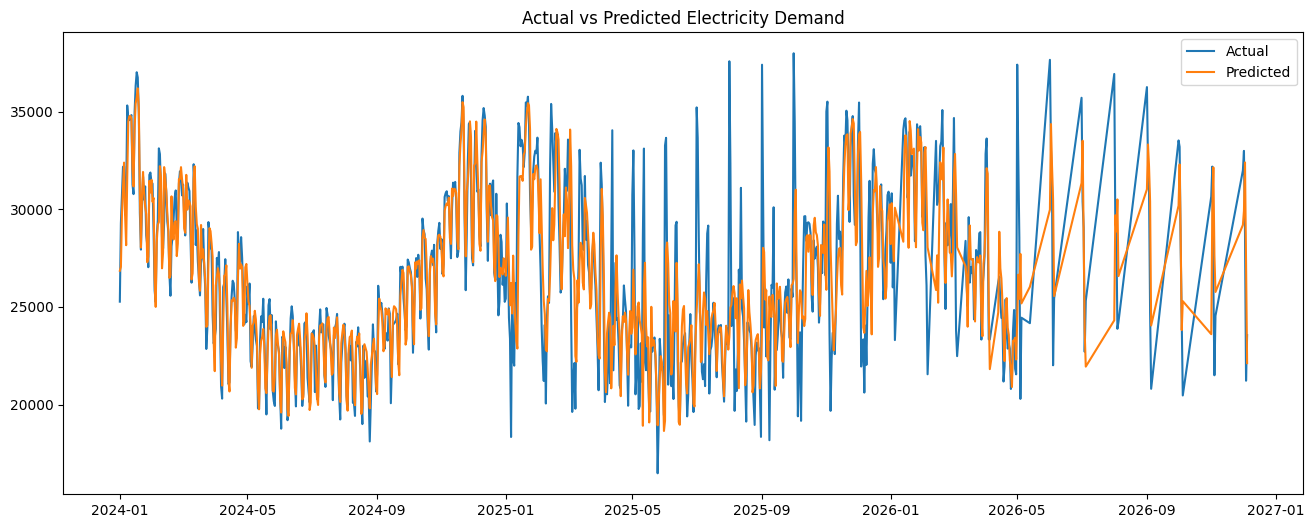

In [12]:
import matplotlib.pyplot as plt

results = test.copy()

results["Prediction"] = predictions

plt.figure(figsize=(16,6))

plt.plot(
    results["SETTLEMENT_DATE"],
    results["ND"],
    label="Actual"
)

plt.plot(
    results["SETTLEMENT_DATE"],
    results["Prediction"],
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted Electricity Demand"
)

plt.show()

In [13]:
plt.savefig(
    "../reports/figures/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [14]:
import joblib

joblib.dump(
    model,
    "../models/xgboost_energy_forecaster.pkl"
)

['../models/xgboost_energy_forecaster.pkl']

In [15]:
import joblib

model = joblib.load(
    "../models/xgboost_energy_forecaster.pkl"
)

In [16]:
import joblib

joblib.dump(
    model,
    "../models/xgboost_energy_forecaster.pkl"
)

print("Model saved")

Model saved


In [17]:
type(model)

xgboost.sklearn.XGBRegressor